In [1]:
!pip install timm

In [2]:
#Imports + GPU Setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import timm

from tqdm import tqdm


# GPU Setup
device = torch.device("cuda")

print("Using device:", device)
print("GPU Name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU Name: Tesla T4


In [3]:
#Dataset Loading

DATA_DIR = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"
df = pd.read_csv(f"{DATA_DIR}/HAM10000_metadata.csv")

df.head()


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [4]:
#Image Path Mapping
image_dir_1 = f"{DATA_DIR}/HAM10000_images_part_1"
image_dir_2 = f"{DATA_DIR}/HAM10000_images_part_2"

image_paths = {}

for folder in [image_dir_1, image_dir_2]:
    for img in os.listdir(folder):
        image_id = img.split(".")[0]
        image_paths[image_id] = os.path.join(folder, img)

df["image_path"] = df["image_id"].map(image_paths)

In [5]:
#Label Encoding + Splits
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["dx"])

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

In [6]:
#Transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
#Dataset Class

class HAM10000Dataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")

        label = row["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
#Datasets + DataLoaders

train_dataset = HAM10000Dataset(
    train_df,
    transform=train_transform
)

val_dataset = HAM10000Dataset(
    val_df,
    transform=val_test_transform
)

test_dataset = HAM10000Dataset(
    test_df,
    transform=val_test_transform
)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [9]:
#Load TinyViT

model = timm.create_model(
    "tiny_vit_5m_224",
    pretrained=True,
    num_classes=7
)

model = model.to(device)

print("Model loaded successfully")

model.safetensors:   0%|          | 0.00/48.4M [00:00<?, ?B/s]

Model loaded successfully


In [10]:
#Loss Function + Optimizer

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

EPOCHS = 20

In [11]:
#Training Function

def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader, leave=True)

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [12]:
#Validation Function

def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    epoch_loss = running_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_labels, all_preds

In [13]:
#Main Training Loop
##
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, val_labels, val_preds = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")


Epoch [1/20]


100%|██████████| 220/220 [01:15<00:00,  2.93it/s, loss=0.989]


Train Loss: 0.8083
Train Accuracy: 0.7322
Validation Loss: 0.6009
Validation Accuracy: 0.7903

Epoch [2/20]


100%|██████████| 220/220 [00:52<00:00,  4.23it/s, loss=0.565]


Train Loss: 0.5501
Train Accuracy: 0.8036
Validation Loss: 0.4864
Validation Accuracy: 0.8442

Epoch [3/20]


...

Train Loss: 0.0742
Train Accuracy: 0.9759
Validation Loss: 0.3822
Validation Accuracy: 0.8815

Epoch [19/20]


100%|██████████| 220/220 [00:51<00:00,  4.30it/s, loss=0.012] 


Train Loss: 0.0939
Train Accuracy: 0.9631
Validation Loss: 0.4003
Validation Accuracy: 0.8862

Epoch [20/20]


100%|██████████| 220/220 [00:51<00:00,  4.24it/s, loss=0.000603]


Train Loss: 0.0637
Train Accuracy: 0.9780
Validation Loss: 0.4267
Validation Accuracy: 0.8755


In [15]:
test_loss, test_acc, test_labels, test_preds = validate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.4710
Test Accuracy: 0.8716


In [16]:
class_names = label_encoder.classes_

print(classification_report(
    test_labels,
    test_preds,
    target_names=class_names
))

              precision    recall  f1-score   support

       akiec       0.80      0.67      0.73        49
         bcc       0.82      0.78      0.80        77
         bkl       0.92      0.58      0.71       165
          df       0.90      0.53      0.67        17
         mel       0.58      0.80      0.67       167
          nv       0.94      0.95      0.94      1006
        vasc       0.91      0.91      0.91        22

    accuracy                           0.87      1503
   macro avg       0.84      0.75      0.78      1503
weighted avg       0.88      0.87      0.87      1503



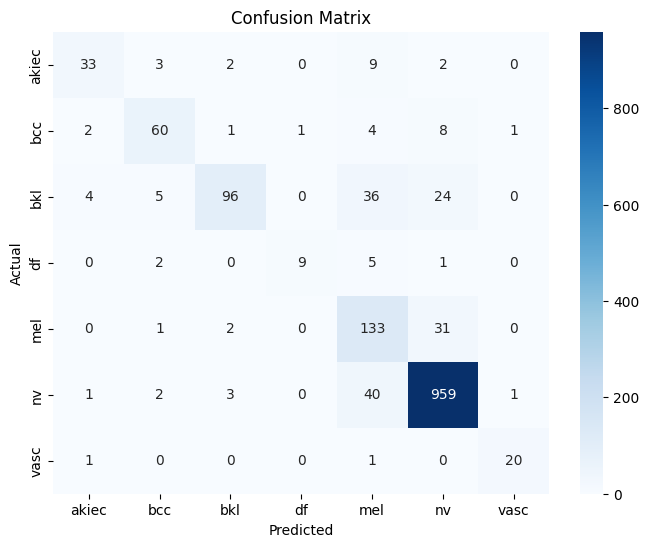

In [17]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [19]:
report = classification_report(
    test_labels,
    test_preds,
    target_names=class_names
)

with open("tinyvit_classification_report.txt", "w") as f:
    f.write(report)

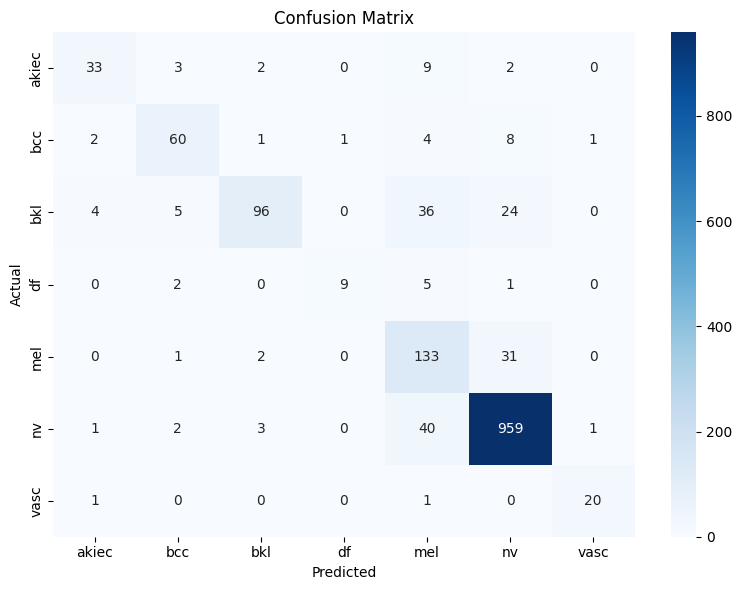

In [22]:
import os

os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "figures/tinyvit_confusion_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()